In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.special import eval_legendre
from scipy.optimize import brentq
from sklearn.model_selection import train_test_split
from RegressFunctions import *
import itertools

In [5]:
class RidgeScaling_ToyData:
    def __init__(self, N, Ps, sigma, λ, r, a, filt=False, center=False, scale=False, kern=None):
        # --- store the config ---
        self.N, self.Ps, self.sigma, self.λ, self.r, self.a = N, Ps, sigma, λ, r, a
        self.filt, self.center, self.scale, self.kern = filt, center, scale, kern
        self.k = np.arange(1, N + 1).astype(float)

        # --- build spectrum + teacher right away (both cheap) ---
        self.eta    = self.k ** (-a)                              # covariance spectrum 
        self.w_true = self.k ** (-(1 + a * (2*r - 1)) / 2)
        self.w_true /= np.linalg.norm(self.w_true)                # teacher spectrum

        # --- filled in by the methods below ---
        self.X = self.y = self.loss = None

    def sample(self, n_samples, seed=0):
        rng = np.random.default_rng(seed)
        self.X = rng.standard_normal((n_samples, self.N)) * np.sqrt(self.eta)   # <- plot histograms
        self.y = self.X @ self.w_true + rng.standard_normal(n_samples) * self.sigma
        return self                                        

    def sweep(self, n_repeats):
        self.loss = run_regression_sweep(self.X, self.y, self.Ps, self.λ, n_repeats, test_size=0.2, w_true=self.w_true,
                                          filter_zero_var=self.filt, center=self.center, scale=self.scale, kern=self.kern)[0]
        return self

## UNDER-PARAMETERIZED 

In [59]:
## ==== UNDERPARAMETERIZED ==== ## 
# fixed for all runs
N, sigma = 100, 0.1
Ps = np.unique(np.round(np.logspace(0, 4.5, 60)).astype(int))
n_reps = lambda P: max(int(1000 / P), 10)

# swept
a_s = [1.1, 1.8, 2.5, 6]
# a_s = [1.1]
r_s = [1.8, 0.5]
λ_s = [1e-10]

experiments_under = {}
for a, r, λ in itertools.product(a_s, r_s, λ_s):
    print(f"a={a}, r={r}, λ={λ}")
    exp = RidgeScaling_ToyData(N=N, Ps=Ps, sigma=sigma, λ=λ, r=r, a=a, filt=False, center=False, scale=False)
    exp.sample(100_000).sweep(n_reps)    
    experiments_under[(a, r, λ)] = exp

a=1.1, r=1.8, λ=1e-10
       1  |  0.680157
       2  |  0.497891
       3  |  0.383557
       4  |  0.294054
       5  |  0.225768
       6  |  0.183541
       7  |  0.145600
       8  |  0.110579
      10  |  0.079773
      12  |  0.050332
      14  |  0.036099
      17  |  0.025707
      20  |  0.018439
      24  |  0.014170
      28  |  0.012177
      34  |  0.012262
      40  |  0.011743
      48  |  0.013933
      57  |  0.016976
      68  |  0.029274
      81  |  0.049911
      96  |  0.281731
     115  |  0.075448
     137  |  0.032858
     163  |  0.014697
     194  |  0.011588
     231  |  0.008240
     276  |  0.005348
     329  |  0.004506
     392  |  0.003259
     467  |  0.002939
     557  |  0.002018
     664  |  0.002053
     791  |  0.001477
     943  |  0.001192
    1124  |  0.000932
    1340  |  0.000833
    1597  |  0.000656
    1904  |  0.000590
    2270  |  0.000489
    2705  |  0.000411
    3225  |  0.000346
    3844  |  0.000300
    4582  |  0.000247
    5461  

## OVER-PARAMETERIZED

In [68]:
## ==== OVERPARAMETERIZED ==== ## 
# fixed for all runs
N, sigma = 10_000, 0
Ps = np.unique(np.round(np.logspace(0, 3.5, 60)).astype(int))
n_reps = lambda P: max(int(500 / P), 10)

# swept
a_s = [1.1, 1.8, 2.5, 6]
# a_s = [1.1]
r_s = [0.5, 1.8]
λ_s = [1e-10]

experiments_over = {}
for a, r, λ in itertools.product(a_s, r_s, λ_s):
    print(f"a={a}, r={r}, λ={λ}")
    exp = RidgeScaling_ToyData(N=N, Ps=Ps, sigma=sigma, λ=λ, r=r, a=a, filt=True, center=False, scale=False)
    exp.sample(5_000).sweep(n_reps)
    experiments_over[(a, r, λ)] = exp

a=1.1, r=0.5, λ=1e-10
       1  |  0.133110
       2  |  0.116956
       3  |  0.099799
       4  |  0.086654
       5  |  0.077714
       6  |  0.065876
       7  |  0.055674
       8  |  0.059390
       9  |  0.057975
      10  |  0.049550
      12  |  0.044277
      13  |  0.039453
      15  |  0.036648
      18  |  0.025491
      20  |  0.024121
      23  |  0.021332
      27  |  0.015068
      30  |  0.015381
      35  |  0.013691
      40  |  0.012330
      46  |  0.007625
      53  |  0.007932
      60  |  0.007124
      69  |  0.005678
      79  |  0.004439
      91  |  0.004063
     104  |  0.003532
     119  |  0.002936
     137  |  0.002533
     157  |  0.002183
     180  |  0.001793
     206  |  0.001490
     236  |  0.001344
     271  |  0.001111
     310  |  0.000947
     356  |  0.000809
     408  |  0.000666
     467  |  0.000579
     536  |  0.000463
     614  |  0.000402
     704  |  0.000329
     807  |  0.000281
     925  |  0.000235
    1060  |  0.000195
    1215  

## OVER-PARAMETERIZED (with NTK) 

In [88]:
## ==== NTK (OVERPARAMETERIZED) ==== ## 
# fixed for all runs
N, sigma = 10_000, 0
Ps = np.unique(np.round(np.logspace(0, 3.5, 60)).astype(int))
n_reps = lambda P: max(int(500 / P), 10)

# swept
a_s = [1.1, 1.8, 2.5, 6]
# a_s = [1.1]
r_s = [0.5, 1.8]
λ_s = [1e-10]

experiments_ntk = {}
for a, r, λ in itertools.product(a_s, r_s, λ_s):
    print(f"a={a}, r={r}, λ={λ}")
    exp = RidgeScaling_ToyData(N=N, Ps=Ps, sigma=sigma, λ=λ, r=r, a=a, filt=True, center=False, scale=False, kern="NTK")
    exp.sample(5_000).sweep(n_reps)    
    experiments_ntk[(a, r, λ)] = exp

a=1.1, r=0.5, λ=1e-10
       1  |  0.148695
       2  |  0.138154
       3  |  0.127635
       4  |  0.117879
       5  |  0.109155
       6  |  0.095860
       7  |  0.087388
       8  |  0.086877
       9  |  0.088138
      10  |  0.077705
      12  |  0.070165
      13  |  0.066062
      15  |  0.062541
      18  |  0.051029
      20  |  0.044170
      23  |  0.038900
      27  |  0.030244
      30  |  0.030053
      35  |  0.026181
      40  |  0.024448
      46  |  0.015667
      53  |  0.015788
      60  |  0.015350
      69  |  0.012440
      79  |  0.009664
      91  |  0.008697
     104  |  0.007821
     119  |  0.006588
     137  |  0.005740
     157  |  0.005011
     180  |  0.004152
     206  |  0.003635
     236  |  0.003199
     271  |  0.002745
     310  |  0.002289
     356  |  0.002042
     408  |  0.001687
     467  |  0.001528
     536  |  0.001244
     614  |  0.001079
     704  |  0.000896
     807  |  0.000776
     925  |  0.000675
    1060  |  0.000590
    1215  

# Plot Spectra

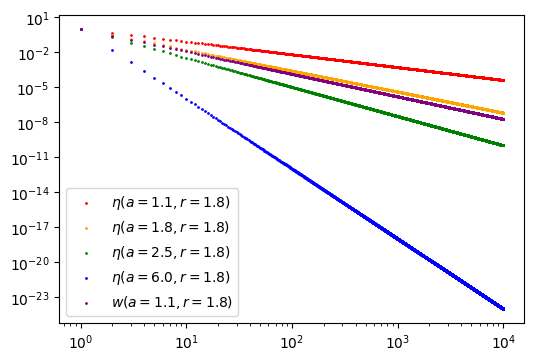

In [9]:
plt.figure(figsize=(6,4))
e_o = experiments_over
plt.scatter(e_o[(1.1, 1.8, 1e-4)].k, e_o[(1.1, 1.8, 1e-4)].eta, s=1, color='r') 
plt.scatter(e_o[(1.8, 1.8, 1e-4)].k, e_o[(1.8, 1.8, 1e-4)].eta, s=1, color='orange') 
plt.scatter(e_o[(2.5, 1.8, 1e-4)].k, e_o[(2.5, 1.8, 1e-4)].eta, s=1, color='g') 
plt.scatter(e_o[(6.0, 1.8, 1e-4)].k, e_o[(6.0, 1.8, 1e-4)].eta, s=1, color='b') 
plt.scatter(e_o[(1.1, 1.8, 1e-4)].k, e_o[(1.1, 1.8, 1e-4)].w_true, s=1, color='purple') 

plt.xscale('log'); plt.yscale('log')
plt.legend([r'$\eta(a=1.1, r=1.8)$', r'$\eta(a=1.8, r=1.8)$', 
            r'$\eta(a=2.5, r=1.8)$', r'$\eta(a=6.0, r=1.8)$',r'$w(a=1.1, r=1.8)$'])

In [1]:
## Plot NTK Spectrum ## 

def kernel_spectrum(X, kernel=None, M=5000, seed=0):
    """Empirical Mercer spectrum under the distribution of rows of X."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), min(M, len(X)), replace=False)
    Xs = torch.as_tensor(np.asarray(X)[idx], dtype=torch.float64)
    K = ntk(Xs, Xs) if kernel == "NTK" else Xs @ Xs.T
    # return np.clip(np.linalg.eigvalsh((K / len(idx)).numpy())[::-1], 1e-300, None)
    return np.linalg.eigvalsh((K / len(idx)).numpy())[::-1]


def fit_spectrum_exponent(ev, lo=10, hi=None):
    """Fit ev[i] ~ i**-b over the reliable window; b is your effective 'a'."""
    hi = hi or len(ev) // 4
    i = np.arange(lo, hi)
    return -np.polyfit(np.log(i + 1.), np.log(ev[lo:hi]), 1)[0]


In [2]:
LNR_spec_a1p1 = kernel_spectrum(experiments_over[(1.1, 1.8, 1e-10)].X, kernel=None)
LNR_spec_a2p5 = kernel_spectrum(experiments_over[(2.5, 1.8, 1e-10)].X, kernel=None)
LNR_spec_a6p0 = kernel_spectrum(experiments_over[(6.0, 1.8, 1e-10)].X, kernel=None)

NTK_spec_a1p1 = kernel_spectrum(experiments_over[(1.1, 1.8, 1e-10)].X, kernel="NTK")
NTK_spec_a2p5 = kernel_spectrum(experiments_over[(2.5, 1.8, 1e-10)].X, kernel="NTK")
NTK_spec_a6p0 = kernel_spectrum(experiments_over[(6.0, 1.8, 1e-10)].X, kernel="NTK")


# print(np.shape(experiments_over[(1.1, 1.8, 1e-4)].k), np.shape(NTK_spec))
# plt.scatter(experiments_over[(1.1, 1.8, 1e-4)].k, NTK_spec)

NameError: name 'experiments_over' is not defined

In [3]:
i = np.arange(1, len(LNR_spec_a1p1)+1)
plt.loglog(i, LNR_spec_a1p1/LNR_spec_a1p1[0], ms=2, color='r', linestyle='--'); 
plt.loglog(i, LNR_spec_a2p5/LNR_spec_a2p5[0], ms=2, color='b', linestyle='--'); 
plt.loglog(i, LNR_spec_a6p0/LNR_spec_a6p0[0], ms=2, color='g', linestyle='--'); 

plt.loglog(i, NTK_spec_a1p1/NTK_spec_a1p1[0], ms=2, color='r', linestyle='-'); 
plt.loglog(i, NTK_spec_a2p5/NTK_spec_a2p5[0], ms=2, color='b', linestyle='-'); 
plt.loglog(i, NTK_spec_a6p0/NTK_spec_a6p0[0], ms=2, color='g', linestyle='-'); 
# plt.loglog(i, i**-1.1, 'r-'); 
# plt.loglog(i, i**-2.5, 'b-'); 

plt.legend(['none, a = 1.1', 'none, a = 2.5', 'none, a = 6.0', 
            'NTK, a = 1.1', 'NTK, a = 2.5',  'NTK, a = 6.0',])


NameError: name 'np' is not defined

In [4]:
FIT_LO, FIT_HI = 10, 500          # <-- index window for the fit

def fit_spec(ev, lo, hi):
    i = np.arange(lo, min(hi, len(ev)))
    y = ev[i]
    m = y > y[0] * 1e-30                      # drop numerically-zero tail
    slope, logA = np.polyfit(np.log(i[m] + 1.), np.log(y[m]), 1)
    return np.exp(logA), -slope

specs  = {('none', 1.1): LNR_spec_a1p1, ('none', 2.5): LNR_spec_a2p5, ('none', 6.0): LNR_spec_a6p0,
          ('NTK',  1.1): NTK_spec_a1p1, ('NTK',  2.5): NTK_spec_a2p5, ('NTK',  6.0): NTK_spec_a6p0}
colors = {1.1: 'r', 2.5: 'b', 6.0: 'g'}
styles = {'none': '--', 'NTK': '-'}

plt.figure(figsize=(7, 5))
i = np.arange(1, len(NTK_spec_a1p1) + 1)
for (kind, a), ev in specs.items():
    evn = ev / ev[0]
    A, b = fit_spec(evn, FIT_LO, FIT_HI)
    plt.loglog(i, evn, color=colors[a], ls=styles[kind], lw=1, label=f'{kind}, a={a}:  b={b:.2f}')
    ifit = np.array([FIT_LO, FIT_HI], float)
    plt.loglog(ifit, A * ifit**-b, color=colors[a], lw=3, alpha=0.4)

plt.axvspan(FIT_LO, FIT_HI, color='gray', alpha=0.12)
plt.xlabel('index $i$'); plt.ylabel(r'$\lambda_i/\lambda_1$')
plt.legend(fontsize=7); plt.ylim(1e-9, 2)


NameError: name 'LNR_spec_a1p1' is not defined

In [5]:
plt.figure(figsize=(6,4))

plt.hist(experiments_over[(1.1, 1.8, 1e-4)].X[:,0], histtype='step', bins=20);
plt.hist(experiments_over[(1.1, 1.8, 1e-4)].X[:,10], histtype='step', bins=20);
plt.hist(experiments_over[(6.0, 1.8, 1e-4)].X[:,1], histtype='step', bins=20);
plt.hist(experiments_over[(6.0, 1.8, 1e-4)].X[:,2], histtype='step', bins=20);
plt.legend([r'Feature 0, $a=1.1$', r'Feature 10, $a=1.1$', 
            r'Feature 1, $a=6.0$', r'Feature 2, $a=6.0$' ])

NameError: name 'plt' is not defined

In [6]:
## ==== Plot losses[r][a] ==== ## 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

styles = ['k--', 'r--', 'b--', 'g--']
colors = ['k', 'r', 'b', 'g']

###### ======== Experiments ========= ######
exp = experiments_ntk
N_features = 10_000
lambda_ridge = 1e-4
### ==================================== ### 

r = 1.8
for (a, c, s) in zip(a_s, colors, styles): 
    print(a,c,s)
    e = exp[(a, r, lambda_ridge)]
    print(np.shape(e.Ps), np.shape(e.loss))
    axes[0].scatter(e.Ps, e.loss, s=12, color=c)
    # Plot Theory (Cengiz)
    axes[0].plot(e.Ps[e.Ps <= N_features], e.Ps[e.Ps <= N_features]**(-2.*a), s)
    axes[0].plot(e.Ps[e.Ps > N_features], e.Ps[e.Ps > N_features]**(-1.), s)
    axes[0].axvline((lambda_ridge)**(-1/a), color=c, ls='--', alpha=0.4)
    # break
axes[0].axvline(N_features, color='orange')
axes[0].text(1.6e3, 1e-1, r'$N = 10^{4}$', color='orange')

## Plot r = 0.5, different a's , lambda = 1e-4
r = 0.5
for (a, c, s) in zip(a_s, colors, styles): 
    e = exp[(a, r, lambda_ridge)]
    axes[1].scatter(e.Ps, e.loss, s=12, color=c)
    # Plot Theory (Cengiz) 
    axes[1].plot(e.Ps[e.Ps <= N_features], e.Ps[e.Ps <= N_features]**(-2.*a*r), s)
    axes[1].plot(e.Ps[e.Ps > N_features], e.Ps[e.Ps > N_features]**(-1.), s)
    axes[1].axvline((lambda_ridge)**(-1/a), color=c, ls='--', alpha=0.4)
    # break
axes[1].axvline(N_features, color='orange')
axes[1].text(1.6e3, 0.4e-1, r'$N = 10^{4}$', color='orange')

for ax, r in zip(axes, [1.8, 0.5]): 
    # [ax.plot(Ps, Ps**(-2*a)) for a in a_s]
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('P'); ax.set_ylabel('Test Loss')
    ax.set_title(rf'$r = {r}, \, \lambda = 10^{{-4}}, \, \sigma = 0$')

axes[0].set_ylim(1e-8, 3e0)
axes[1].set_ylim(1e-6, 3e0)
axes[0].set_xlim(1e0, 3e4)
axes[1].set_xlim(1e0, 3e4)
axes[0].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'], loc='lower left')
axes[1].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'])
handles = [plt.Line2D([], [], marker='o', linestyle='', color=c, markersize=3) for c in colors]
axes[0].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')
axes[1].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')

NameError: name 'plt' is not defined

In [7]:
def fit_powerlaw(P, loss, pmin, pmax):
    """Fit loss ~ A * P**-alpha over [pmin, pmax]. Returns (A, alpha)."""
    P, loss = np.asarray(P, float), np.asarray(loss, float)
    m = (P >= pmin) & (P <= pmax) & (loss > 0)
    slope, logA = np.polyfit(np.log(P[m]), np.log(loss[m]), 1)
    return np.exp(logA), -slope


FIT_MIN, FIT_MAX = 100, 1000          # <-- tune these
exp, lambda_ridge = experiments_ntk, 1e-10
colors = ['k', 'r', 'b', 'g']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, r in zip(axes, [1.8, 0.5]):
    for a, c in zip(a_s, colors):
        e = exp[(a, r, lambda_ridge)]
        A, alpha = fit_powerlaw(e.Ps, e.loss, FIT_MIN, FIT_MAX)
        theory = 2*a if r > 1 else 2*a*r
        ax.scatter(e.Ps, e.loss, s=12, color=c,
                   label=f'a={a}:  fit {-alpha:.2f}   (theory {-theory:.2f})')
        Pf = np.array([FIT_MIN, FIT_MAX], float)
        ax.plot(Pf, A*Pf**-alpha, color=c, ls='--', lw=1.5)
    ax.axvspan(FIT_MIN, FIT_MAX, color='gray', alpha=0.12)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('P'); ax.set_ylabel('Test Loss')
    ax.set_title(rf'$r={r},\ \lambda=10^{{-10}},\ \sigma=0$')
    ax.legend(fontsize=7, loc='lower left')


NameError: name 'experiments_ntk' is not defined

In [8]:
lam, r = 1e-10, 1.8
colors = ['k', 'r', 'b', 'g']

plt.figure(figsize=(7, 5))
for a, c in zip(a_s, colors):
    e = experiments_ntk[(a, r, lam)]
    eigs, v2 = spectrum_and_target(e.X, e.X @ e.w_true, kernel="NTK")
    pred = np.array([eg_theory(eigs, v2, P, lam)[0] for P in e.Ps])
    plt.scatter(e.Ps, e.loss, s=12, color=c, label=f'a={a}  measured')
    plt.plot(e.Ps, pred, color=c, lw=1.5, label=f'a={a}  Eq. 25')

plt.xscale('log'); plt.yscale('log')
plt.xlabel('P'); plt.ylabel('Test Loss')
plt.title(rf'NTK: measured vs Eq. 25,  $r={r}$, $\lambda=10^{{-4}}$')
plt.legend(fontsize=7, ncol=2)


NameError: name 'plt' is not defined

KeyError: (1.1, 1.8, 1e-10)

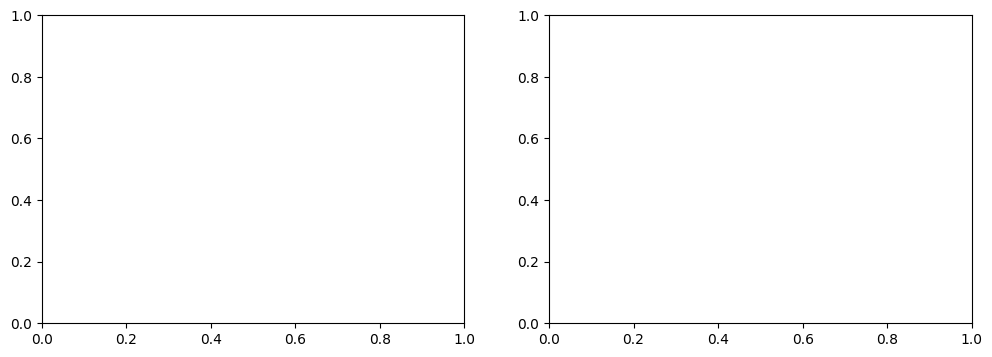

In [8]:
## ==== Plot losses[r][a] ==== ## 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

styles = ['k--', 'r--', 'b--', 'g--']
colors = ['k', 'r', 'b', 'g']

## Plot r = 1.8, different a's , lambda = 1e-4
r = 1.8
for (a, c, s) in zip(a_s, colors, styles): 
    e = experiments_over[(a, r, 1e-10)]
    axes[0].scatter(e.Ps, e.loss, s=12, color=c)
    axes[0].plot(e.Ps, e.Ps**(-2.*a), s)
    axes[0].axvline((1e-10)**(-1/a), color=c, ls='--', alpha=0.4)
axes[0].axvline(1e4, color='orange')
axes[0].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')

## Plot r = 0.5, different a's , lambda = 1e-4
r = 0.5
for (a, c, s) in zip(a_s, colors, styles): 
    e = experiments_over[(a, r, 1e-10)]
    axes[1].scatter(e.Ps, e.loss, s=12, color=c)
    axes[1].plot(e.Ps, e.Ps**(-2.*a*r), s)
    axes[1].axvline((1e-10)**(-1/a), color=c, ls='--', alpha=0.4)
axes[1].axvline(1e4, color='orange')
axes[1].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')

for ax, r in zip(axes, [1.8, 0.5]): 
    # [ax.plot(Ps, Ps**(-2*a)) for a in a_s]
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('P'); ax.set_ylabel('Test Loss')
    ax.set_title(rf'$r = {r}, \, \lambda = 10^{{-10}}, \, \sigma = 0$')

axes[0].set_ylim(1e-21, 3e0); axes[0].set_xlim(0.9e0, 3e4); 
axes[1].set_ylim(1e-14, 3e0); axes[1].set_xlim(0.9e0, 3e4); 
axes[0].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'], loc='lower left')
axes[1].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'])
handles = [plt.Line2D([], [], marker='o', linestyle='', color=c, markersize=3) for c in colors]
axes[0].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')
axes[1].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')

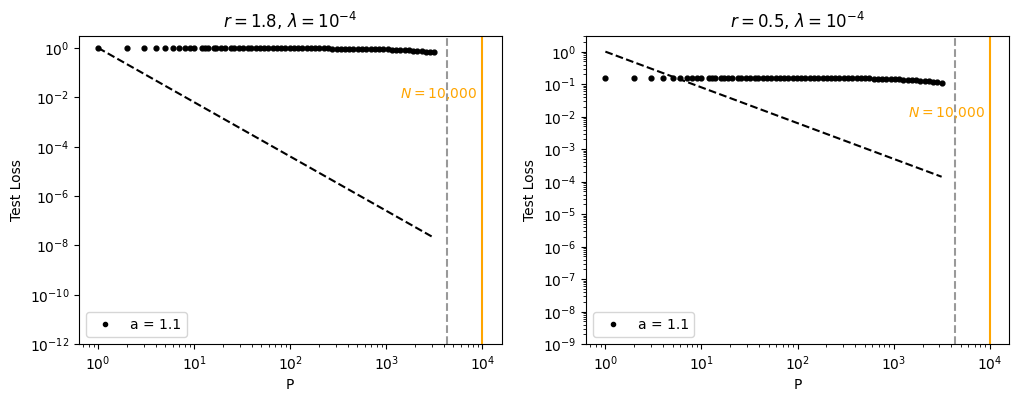

In [10]:
## ==== Plot losses[r][a] ==== ## 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

styles = ['k--', 'r--', 'b--', 'g--']
colors = ['k', 'r', 'b', 'g']

#                   a,  r,   lambda
exp = experiments_over[(1.1, 1.8, 1e-4)]
## Plot r = 1.8, different a's , lambda = 1e-4
r = 1.8
for (a, c, s) in zip(a_s, colors, styles): 
    e = experiments_over[(a, r, 1e-4)]
    axes[0].scatter(e.Ps, e.loss, s=12, color=c)
    axes[0].plot(e.Ps, e.Ps**(-2.*a), s)
    axes[0].axvline((1e-4)**(-1/a), color=c, ls='--', alpha=0.4)
axes[0].axvline(10_000, color='orange')
axes[0].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')

## Plot r = 0.5, different a's , lambda = 1e-4
r = 0.5
for (a, c, s) in zip(a_s, colors, styles): 
    e = experiments_over[(a, r, 1e-4)]
    axes[1].scatter(e.Ps, e.loss, s=12, color=c)
    axes[1].plot(e.Ps, e.Ps**(-2.*a*r), s)
    axes[1].axvline((1e-4)**(-1/a), color=c, ls='--', alpha=0.4)
axes[1].axvline(10_000, color='orange')
axes[1].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')

for ax, r in zip(axes, [1.8, 0.5]): 
    # [ax.plot(Ps, Ps**(-2*a)) for a in a_s]
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('P'); ax.set_ylabel('Test Loss')
    ax.set_title(rf'$r = {r}, \, \lambda = 10^{{-4}}$')

axes[0].set_ylim(1e-12, 3e0)
axes[1].set_ylim(1e-9, 3e0)
axes[0].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'], loc='lower left')
axes[1].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'])
handles = [plt.Line2D([], [], marker='o', linestyle='', color=c, markersize=3) for c in colors]
axes[0].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')
axes[1].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')

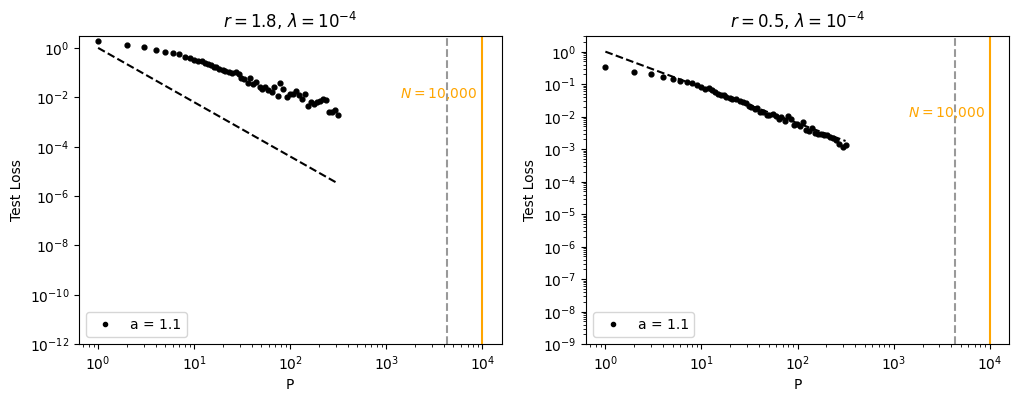

In [16]:
## ==== Plot losses[r][a] ==== ## 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

styles = ['k--', 'r--', 'b--', 'g--']
colors = ['k', 'r', 'b', 'g']

#                   a,  r,   lambda
exp = experiments[(1.1, 1.8, 1e-4)]
## Plot r = 1.8, different a's , lambda = 1e-4
r = 1.8
for (a, c, s) in zip(a_s, colors, styles): 
    e = experiments[(a, r, 1e-4)]
    axes[0].scatter(e.Ps, e.loss, s=12, color=c)
    axes[0].plot(e.Ps, e.Ps**(-2.*a), s)
    axes[0].axvline((1e-4)**(-1/a), color=c, ls='--', alpha=0.4)
axes[0].axvline(10_000, color='orange')
axes[0].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')

## Plot r = 0.5, different a's , lambda = 1e-4
r = 0.5
for (a, c, s) in zip(a_s, colors, styles): 
    e = experiments[(a, r, 1e-4)]
    axes[1].scatter(e.Ps, e.loss, s=12, color=c)
    axes[1].plot(e.Ps, e.Ps**(-2.*a*r), s)
    axes[1].axvline((1e-4)**(-1/a), color=c, ls='--', alpha=0.4)
axes[1].axvline(10_000, color='orange')
axes[1].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')

for ax, r in zip(axes, [1.8, 0.5]): 
    # [ax.plot(Ps, Ps**(-2*a)) for a in a_s]
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('P'); ax.set_ylabel('Test Loss')
    ax.set_title(rf'$r = {r}, \, \lambda = 10^{{-4}}$')

axes[0].set_ylim(1e-12, 3e0)
axes[1].set_ylim(1e-9, 3e0)
axes[0].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'], loc='lower left')
axes[1].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'])
handles = [plt.Line2D([], [], marker='o', linestyle='', color=c, markersize=3) for c in colors]
axes[0].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')
axes[1].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')

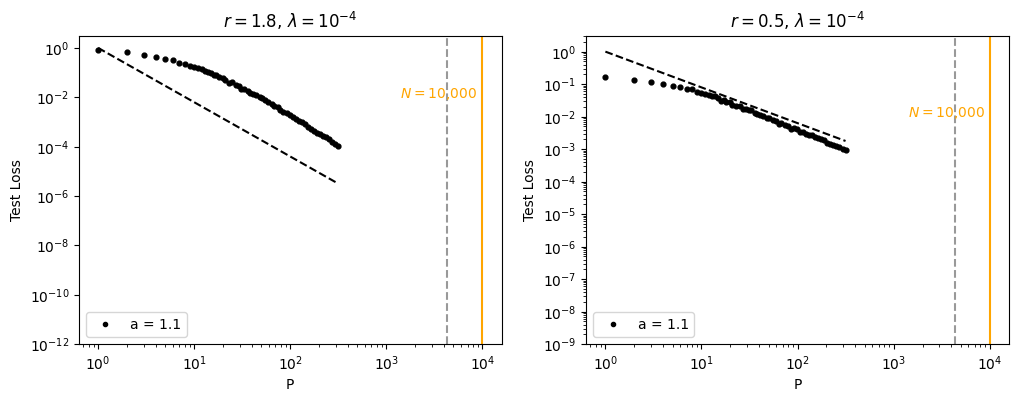

In [8]:
## ==== Plot losses[r][a] ==== ## 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

styles = ['k--', 'r--', 'b--', 'g--']
colors = ['k', 'r', 'b', 'g']

#                   a,  r,   lambda
exp = experiments[(1.1, 1.8, 1e-4)]
## Plot r = 1.8, different a's , lambda = 1e-4
r = 1.8
for (a, c, s) in zip(a_s, colors, styles): 
    e = experiments[(a, r, 1e-4)]
    axes[0].scatter(e.Ps, e.loss, s=12, color=c)
    axes[0].plot(e.Ps, e.Ps**(-2.*a), s)
    axes[0].axvline((1e-4)**(-1/a), color=c, ls='--', alpha=0.4)
axes[0].axvline(10_000, color='orange')
axes[0].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')

## Plot r = 0.5, different a's , lambda = 1e-4
r = 0.5
for (a, c, s) in zip(a_s, colors, styles): 
    e = experiments[(a, r, 1e-4)]
    axes[1].scatter(e.Ps, e.loss, s=12, color=c)
    axes[1].plot(e.Ps, e.Ps**(-2.*a*r), s)
    axes[1].axvline((1e-4)**(-1/a), color=c, ls='--', alpha=0.4)
axes[1].axvline(10_000, color='orange')
axes[1].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')

for ax, r in zip(axes, [1.8, 0.5]): 
    # [ax.plot(Ps, Ps**(-2*a)) for a in a_s]
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('P'); ax.set_ylabel('Test Loss')
    ax.set_title(rf'$r = {r}, \, \lambda = 10^{{-4}}$')

axes[0].set_ylim(1e-12, 3e0)
axes[1].set_ylim(1e-9, 3e0)
axes[0].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'], loc='lower left')
axes[1].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'])
handles = [plt.Line2D([], [], marker='o', linestyle='', color=c, markersize=3) for c in colors]
axes[0].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')
axes[1].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')

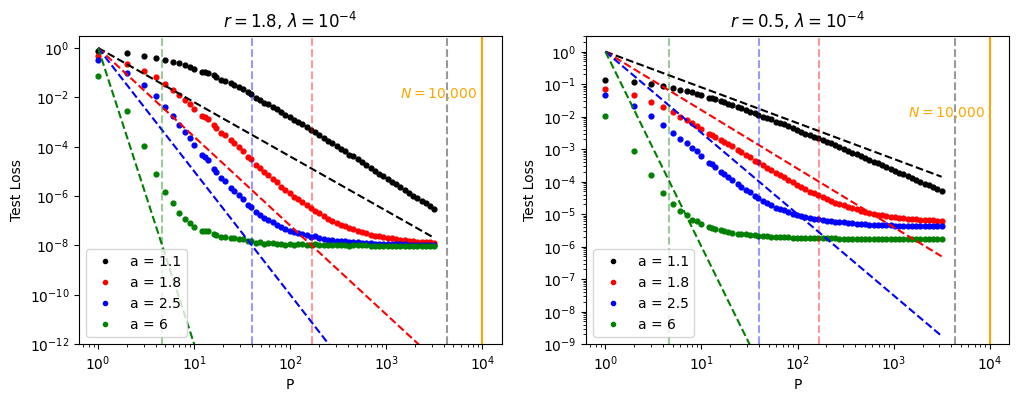

In [ ]:
## ==== Plot losses[r][a] ==== ## 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

styles = ['k--', 'r--', 'b--', 'g--']
colors = ['k', 'r', 'b', 'g']

#                   a,  r,   lambda
exp = experiments_over[(1.1, 1.8, 1e-4)]
## Plot r = 1.8, different a's , lambda = 1e-4
r = 1.8
for (a, c, s) in zip(a_s, colors, styles): 
    e = experiments[(a, r, 1e-4)]
    axes[0].scatter(e.Ps, e.loss, s=12, color=c)
    axes[0].plot(e.Ps, e.Ps**(-2.*a), s)
    axes[0].axvline((1e-4)**(-1/a), color=c, ls='--', alpha=0.4)
axes[0].axvline(10_000, color='orange')
axes[0].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')

## Plot r = 0.5, different a's , lambda = 1e-4
r = 0.5
for (a, c, s) in zip(a_s, colors, styles): 
    e = experiments[(a, r, 1e-4)]
    axes[1].scatter(e.Ps, e.loss, s=12, color=c)
    axes[1].plot(e.Ps, e.Ps**(-2.*a*r), s)
    axes[1].axvline((1e-4)**(-1/a), color=c, ls='--', alpha=0.4)
axes[1].axvline(10_000, color='orange')
axes[1].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')

for ax, r in zip(axes, [1.8, 0.5]): 
    # [ax.plot(Ps, Ps**(-2*a)) for a in a_s]
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('P'); ax.set_ylabel('Test Loss')
    ax.set_title(rf'$r = {r}, \, \lambda = 10^{{-4}}$')

axes[0].set_ylim(1e-12, 3e0)
axes[1].set_ylim(1e-9, 3e0)
axes[0].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'], loc='lower left')
axes[1].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'])
handles = [plt.Line2D([], [], marker='o', linestyle='', color=c, markersize=3) for c in colors]
axes[0].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')
axes[1].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')

In [1]:
## ==== Plot losses[r][a] ==== ## 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

styles = ['k--', 'r--', 'b--', 'g--']
colors = ['k', 'r', 'b', 'g']


## Plot r = 1.8, different a's , lambda = 1e-4
r = 1.8
for (a, c, s) in zip(a_s, colors, styles): 
    e = experiments[(a, r, 1e-10)]
    axes[0].scatter(e.Ps, e.loss, s=12, color=c)
    axes[0].plot(e.Ps, e.Ps**(-2.*a), s)
    axes[0].axvline((1e-10)**(-1/a), color=c, ls='--', alpha=0.4)
axes[0].axvline(10_000, color='orange')
axes[0].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')

## Plot r = 0.5, different a's , lambda = 1e-4
r = 0.5
for (a, c, s) in zip(a_s, colors, styles): 
    e = experiments[(a, r, 1e-10)]
    axes[1].scatter(e.Ps, e.loss, s=12, color=c)
    axes[1].plot(e.Ps, e.Ps**(-2.*a*r), s)
    axes[1].axvline((1e-10)**(-1/a), color=c, ls='--', alpha=0.4)
axes[1].axvline(10_000, color='orange')
axes[1].text(1.4e3, 1e-2, r'$N = 10{,}000$', color='orange')

for ax, r in zip(axes, [1.8, 0.5]): 
    # [ax.plot(Ps, Ps**(-2*a)) for a in a_s]
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('P'); ax.set_ylabel('Test Loss')
    ax.set_title(rf'$r = {r}, \, \lambda = 10^{{-10}}$')

axes[0].set_ylim(1e-20, 3e0)
axes[1].set_ylim(1e-9, 3e0)
axes[0].set_xlim(1e0, 2e4)
axes[1].set_xlim(1e0, 2e4)
axes[0].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'], loc='lower left')
axes[1].legend([f'a = 1.1', f'a = 1.8', f'a = 2.5', r'a = 6.0'])
handles = [plt.Line2D([], [], marker='o', linestyle='', color=c, markersize=3) for c in colors]
axes[0].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')
axes[1].legend(handles, [f'a = {a}' for a in a_s], loc='lower left')

NameError: name 'plt' is not defined